<a href="https://colab.research.google.com/github/adhammkhaled/Pattern-Recognition-Labs/blob/main/Style%20Transfer/cnn_style_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 03

  Style Transfer with Multi-Input Conditioning:
In this assignment, you will implement a neural style transfer pipeline that takes two input images
and a style threshold:
- A content image, such as a photograph of a city or a person
- A style image, such as a painting by Van Gogh or Picasso
- The style threshold is a scalar value that determines the degree to which the style is
transferred onto the content image


Your model will generate a new image that preserves the content of the first image while adopting
the style of the second, modulated by the threshold value. To understand the underlying principles
of neural style transfer, you are expected to read the foundational paper on this topic https://openaccess.thecvf.com/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf

## **Part One**

In [38]:
!pip install kagglehub

In [40]:
import kagglehub
import os
import random
from sklearn.model_selection import train_test_split
from PIL import Image
import shutil

### 1.1. Downloading

In [41]:
# downloading WikiArt style dataset
style_path = kagglehub.dataset_download("steubk/wikiart")
print("WikiArt style images saved to:", style_path)

# downloading content image dataset
content_path = kagglehub.dataset_download("duttadebadri/image-classification")
print("Content images saved to:", content_path)

content_path = os.path.join(content_path, "images", "images")



WikiArt style images saved to: /kaggle/input/wikiart
Content images saved to: /kaggle/input/image-classification


In [42]:
print(os.listdir(content_path))
print("\n")
print(os.listdir(style_path))

['food and d rinks', 'travel and  adventure', 'art and culture', 'architecure']


['Pop_Art', 'Minimalism', 'Color_Field_Painting', 'Mannerism_Late_Renaissance', 'Symbolism', 'Impressionism', 'Contemporary_Realism', 'High_Renaissance', 'Fauvism', 'Rococo', 'Early_Renaissance', 'Naive_Art_Primitivism', 'Pointillism', 'classes.csv', 'Cubism', 'Synthetic_Cubism', 'Action_painting', 'Abstract_Expressionism', 'New_Realism', 'wclasses.csv', 'Baroque', 'Analytical_Cubism', 'Expressionism', 'Romanticism', 'Northern_Renaissance', 'Ukiyo_e', 'Post_Impressionism', 'Art_Nouveau_Modern', 'Realism']


In [43]:
content_image_count = 0
for root, _, files in os.walk(content_path):
    content_image_count += len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"Number of content images: {content_image_count}")




Number of content images: 35093


In [45]:
style_image_count = 0
for subfolder in os.listdir(style_path):
    subfolder_path = os.path.join(style_path, subfolder)
    if os.path.isdir(subfolder_path):
        style_image_count += len([
            f for f in os.listdir(subfolder_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
print(f"Number of style images: {style_image_count}")

Number of style images: 81444


### 1.2. Splitting

In [71]:
# 1. Collect content and style image paths
def get_image_paths(root_dir, limit=None):
    image_paths = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    random.shuffle(image_paths)  # shuffle to get diverse categories
    if limit:
        image_paths = image_paths[:limit]
    return image_paths

content_images = get_image_paths(content_path, limit=5000)
style_images = get_image_paths(style_path, limit=5000)

print(f"Selected content images: {len(content_images)}")
print(f"Selected style images: {len(style_images)}")

# 2. Split into train/val/test
def split_data(images):
    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)
    return train, val, test

content_train, content_val, content_test = split_data(content_images)
style_train, style_val, style_test = split_data(style_images)

# 3. Copy images to new folders
def copy_images(images, base_dir, label):
    for img_path in images:
        filename = os.path.basename(img_path)
        dest_dir = os.path.join(base_dir, label)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(img_path, os.path.join(dest_dir, filename))

base_output = "/content/dataset_split"

# Create folders like /content/dataset_split/content/train, etc.
for split, data in zip(
    ['train', 'val', 'test'],
    [content_train, content_val, content_test]
):
    copy_images(data, os.path.join(base_output, 'content'), split)

for split, data in zip(
    ['train', 'val', 'test'],
    [style_train, style_val, style_test]
):
    copy_images(data, os.path.join(base_output, 'style'), split)

print("Done, dataset is split and stored under /content/dataset_split")


Selected content images: 5000
Selected style images: 5000
Done, dataset is split and stored under /content/dataset_split


In [72]:
def count_images_in_split(base_path, label):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_path, label, split)
        num_images = len([
            f for f in os.listdir(split_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"{label.capitalize()} - {split}: {num_images} images")

# Check content
count_images_in_split("/content/dataset_split", "content")

# Check style
count_images_in_split("/content/dataset_split", "style")


Content - train: 10359 images
Content - val: 2196 images
Content - test: 2190 images
Style - train: 8057 images
Style - val: 1494 images
Style - test: 1488 images


## **Part Two : Data Preprocessing**

In [67]:
import random
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
from PIL import UnidentifiedImageError


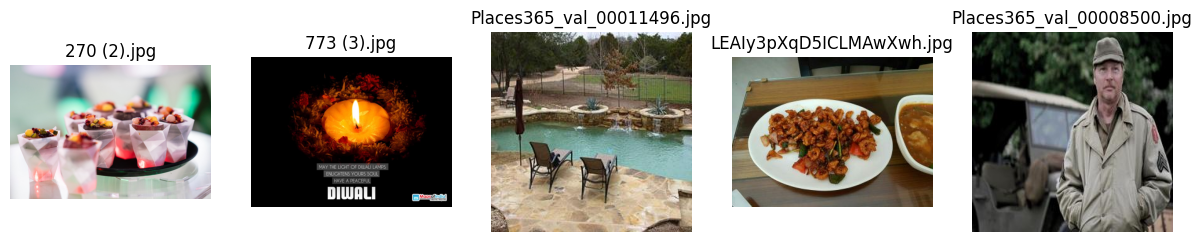

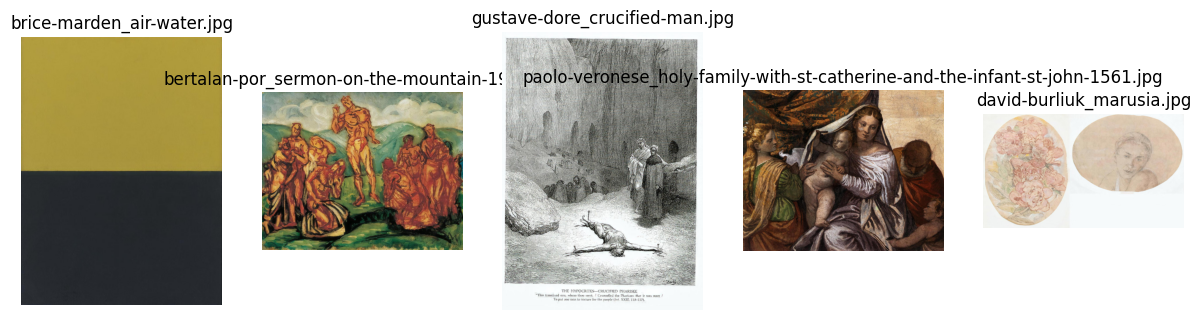

In [73]:
# random images from the dataset split (train/val/test)
def show_images_from_split(split_dir, num_images=5):
    # all image files in the split directory
    image_files = [f for f in os.listdir(split_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    sampled_images = random.sample(image_files, num_images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i, image_name in enumerate(sampled_images):
        img = Image.open(os.path.join(split_dir, image_name))
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(image_name)

    plt.show()


content_train_dir = "/content/dataset_split/content/train"
show_images_from_split(content_train_dir, num_images=5)

print("\n\n")

style_train_dir = "/content/dataset_split/style/train"
show_images_from_split(style_train_dir, num_images=5)


### Checking Corrupted File

In [78]:
from PIL import UnidentifiedImageError

corrupt = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        try:
            img = Image.open(os.path.join(root, file))
            img.verify()  # verifies without loading fully
        except (UnidentifiedImageError, OSError):
            corrupt.append(file)

print(f"Corrupted files: {corrupt}")


Corrupted files: ['Places365_val_00011603.jpg']


Removing the corrupted file

In [80]:
corrupt_file_path = "/content/dataset_split/content/train/Places365_val_00011603.jpg"

if os.path.exists(corrupt_file_path):
    os.remove(corrupt_file_path)
    print(f"Removed: {corrupt_file_path}")
else:
    print(f"File not found: {corrupt_file_path}")


File not found: /content/dataset_split/content/train/Places365_val_00011603.jpg


### Checking Images Sized

In [81]:
sizes = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            img = Image.open(os.path.join(root, file))
            sizes.append(img.size)

from collections import Counter
print(Counter(sizes))  # Shows frequency of each image size


Counter({(320, 320): 2052, (256, 256): 1961, (128, 128): 1908, (320, 240): 623, (100, 100): 257, (427, 240): 133, (321, 240): 114, (360, 240): 83, (426, 240): 75, (1280, 720): 43, (320, 427): 35, (240, 240): 35, (320, 400): 25, (361, 240): 21, (320, 321): 21, (600, 450): 21, (800, 533): 20, (1024, 768): 20, (290, 356): 19, (290, 387): 19, (480, 320): 18, (800, 450): 18, (324, 240): 17, (320, 569): 17, (1024, 683): 17, (290, 361): 16, (290, 226): 15, (240, 320): 14, (290, 388): 14, (290, 365): 13, (640, 480): 12, (600, 600): 12, (290, 376): 12, (336, 240): 12, (800, 600): 12, (759, 422): 12, (600, 400): 11, (500, 500): 11, (320, 480): 11, (290, 377): 11, (480, 360): 10, (290, 330): 10, (213, 320): 10, (290, 360): 10, (290, 244): 10, (1200, 800): 10, (960, 720): 10, (700, 400): 10, (400, 300): 8, (1000, 667): 8, (338, 338): 8, (1000, 1000): 8, (800, 800): 8, (290, 320): 8, (450, 300): 7, (500, 333): 7, (960, 540): 7, (305, 240): 7, (400, 400): 7, (247, 240): 7, (1600, 1200): 6, (427, 320

### Checking Aspect Ratio

In [82]:
ratios = [round(w / h, 2) for w, h in sizes]
print(Counter(ratios))  # common aspect ratios


Counter({1.0: 6388, 1.33: 817, 1.5: 422, 1.78: 319, 1.34: 142, 0.75: 120, 1.77: 92, 0.67: 70, 0.8: 64, 1.51: 63, 1.6: 48, 2.0: 47, 0.77: 44, 0.81: 42, 1.35: 41, 1.49: 39, 1.4: 28, 1.44: 26, 0.56: 26, 1.52: 26, 1.67: 25, 1.62: 25, 1.38: 24, 0.71: 24, 1.8: 24, 1.48: 23, 1.19: 23, 1.75: 23, 1.43: 22, 1.57: 21, 0.79: 21, 1.79: 21, 1.2: 21, 1.36: 21, 1.46: 20, 1.28: 20, 0.66: 19, 1.42: 19, 0.72: 19, 1.53: 19, 1.31: 18, 1.27: 18, 1.54: 17, 1.39: 16, 0.74: 16, 1.32: 16, 1.25: 16, 1.69: 16, 1.56: 16, 1.15: 15, 0.78: 15, 1.01: 14, 1.3: 14, 1.9: 14, 1.41: 14, 1.55: 14, 0.88: 13, 1.47: 13, 1.91: 13, 1.23: 12, 1.03: 12, 0.65: 12, 0.91: 12, 1.72: 12, 1.05: 12, 0.9: 12, 1.65: 11, 0.76: 11, 1.58: 11, 1.22: 11, 1.17: 11, 0.69: 11, 1.45: 11, 1.37: 11, 1.64: 11, 1.63: 11, 1.1: 11, 1.16: 10, 1.85: 10, 1.21: 10, 0.93: 10, 0.96: 10, 1.76: 10, 1.83: 10, 0.82: 10, 1.18: 10, 1.29: 9, 0.73: 9, 1.61: 9, 0.64: 9, 1.02: 9, 1.24: 9, 1.59: 9, 0.85: 9, 0.87: 9, 1.88: 9, 1.07: 9, 0.86: 9, 1.86: 8, 1.68: 8, 0.83: 8, 0

In [84]:
formats = []
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        ext = os.path.splitext(file)[-1].lower()
        formats.append(ext)

print(Counter(formats))


Counter({'.jpg': 9019, '.jpeg': 817, '.png': 522})


### Checking gray scaled images

In [92]:
grayscale_images = []

for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            try:
                img = Image.open(os.path.join(root, file))
                if img.mode != 'RGB':
                    grayscale_images.append(file)
            except Exception:
                pass

print(f"Number of grayscale/non-RGB images: {len(grayscale_images)}")
print("Sample grayscale files:", grayscale_images[:5])


Number of grayscale/non-RGB images: 88
Sample grayscale files: ['212 (2).png', '485 (5).jpg', '89.jpg', '301.png', '203 (2).jpg']


Exists, so will change them to rgb using PIL

In [93]:
for root, _, files in os.walk("/content/dataset_split/content/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            try:
                img_path = os.path.join(root, file)
                img = Image.open(img_path)
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                    img.save(img_path)
            except Exception as e:
                print(f"Error processing {file}: {e}")


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


## Starting Preprocessing

In [85]:
IMAGE_SIZE = (256, 256)


In [86]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),  # to [0, 1]
    # transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),  # normalize to [-1, 1]
])


In [87]:
def create_preprocessed_sample(content_path, style_path, threshold_range=(0.3, 0.8)):
    content_img = transform(Image.open(content_path).convert("RGB"))
    style_img = transform(Image.open(style_path).convert("RGB"))
    threshold = random.uniform(*threshold_range)
    return content_img, style_img, threshold


In [88]:
class StyleTransferDataset(Dataset):
    def __init__(self, content_paths, style_paths, transform, threshold_range=(0.3, 0.8)):
        self.content_paths = content_paths
        self.style_paths = style_paths
        self.transform = transform
        self.threshold_range = threshold_range

    def __len__(self):
        return len(self.content_paths)

    def __getitem__(self, idx):
        content_img = Image.open(self.content_paths[idx]).convert("RGB")
        style_img = Image.open(random.choice(self.style_paths)).convert("RGB")
        content_tensor = self.transform(content_img)
        style_tensor = self.transform(style_img)
        threshold = random.uniform(*self.threshold_range)
        return content_tensor, style_tensor, threshold


In [94]:
train_dataset = StyleTransferDataset(content_train, style_train, transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)


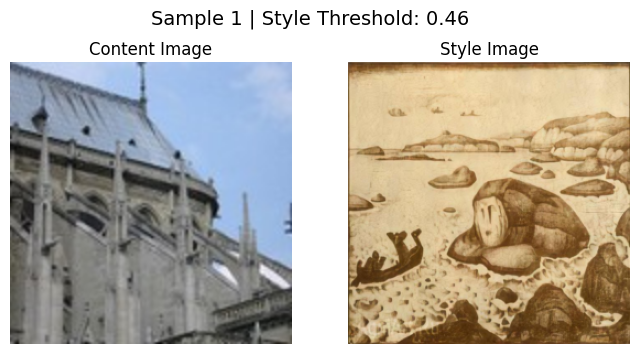

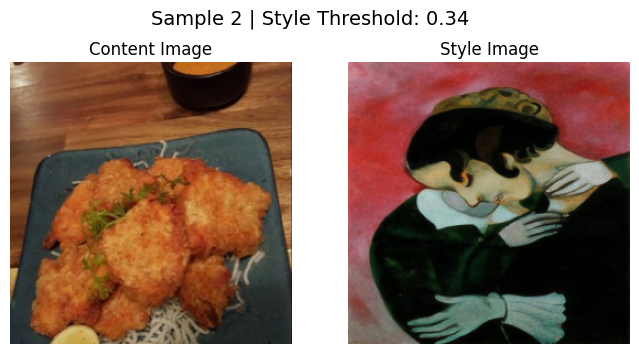

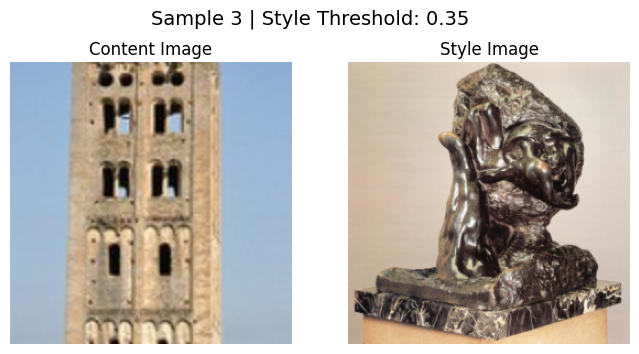

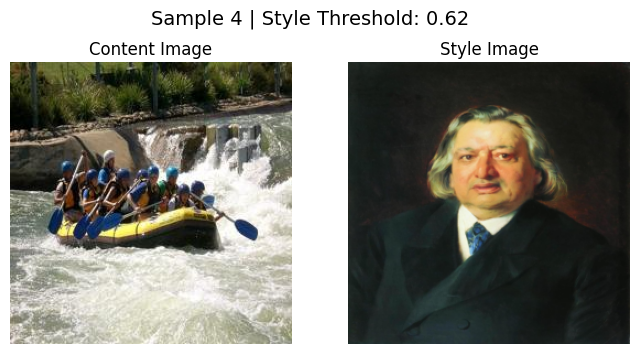

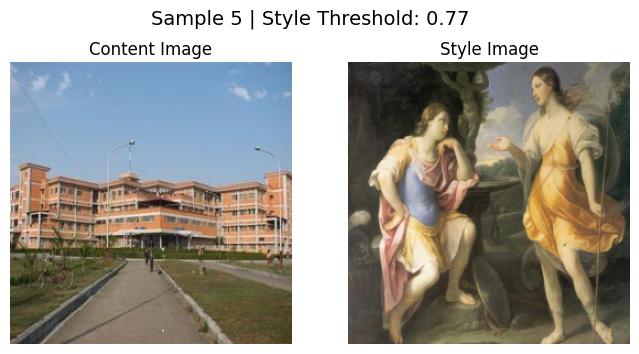

In [95]:
# show a batch of content + style + threshold
def visualize_batch(dataset, num_samples=5):
    for i in range(num_samples):
        content_img, style_img, threshold = dataset[i]

        # Convert tensors to NumPy arrays
        content_np = content_img.permute(1, 2, 0).numpy()
        style_np = style_img.permute(1, 2, 0).numpy()

        # Create subplots
        fig, axs = plt.subplots(1, 2, figsize=(8, 4))
        fig.suptitle(f"Sample {i+1} | Style Threshold: {threshold:.2f}", fontsize=14)

        axs[0].imshow(content_np)
        axs[0].set_title("Content Image")
        axs[0].axis("off")

        axs[1].imshow(style_np)
        axs[1].set_title("Style Image")
        axs[1].axis("off")

        plt.show()

visualize_batch(train_dataset, num_samples=5)


## **Part Three: Creating the Model**